In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import VOCDetection
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torchvision.transforms.v2 as T
import os




In [28]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
model = retinanet_resnet50_fpn_v2(weights=weights, box_score_thresh=0.9)
model.to(device)
model.eval()

# VOC class names
VOC_CLASSES = ['person', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'sheep',
               'chair', 'cow', 'diningtable', 'sofa', 'horse', 'motorbike', 'person',
               'pottedplant', 'cat', 'dog', 'train', 'sheep']

class_to_idx = {cls: i + 1 for i, cls in enumerate(VOC_CLASSES)}  # VOC label IDs: 1–20

# Map COCO class IDs (1-based) to VOC class IDs
COCO_CLASSES = weights.meta["categories"]
coco_to_voc = {COCO_CLASSES.index(cls): class_to_idx[cls] for cls in VOC_CLASSES if cls in COCO_CLASSES}

# Use pretrained transform
preprocess = weights.transforms()

# Custom transform for VOCDetection


In [4]:
def voc_transform(img, target):
    return preprocess(img), target

# Load VOC val set
voc_root = "/content/VOC"
dataset = VOCDetection(root=voc_root, year='2012', image_set='val', download=True, transforms=voc_transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# Evaluation metric
metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)

# Extract GT boxes and labels from VOC
def extract_voc_targets(target):
    boxes = []
    labels = []
    obj_list = target['annotation'].get('object', [])
    if isinstance(obj_list, dict):
        obj_list = [obj_list]

    for obj in obj_list:
        cls_name = obj['name']
        if cls_name not in class_to_idx:
            continue
        bbox = obj['bndbox']
        xmin = float(bbox['xmin'])
        ymin = float(bbox['ymin'])
        xmax = float(bbox['xmax'])
        ymax = float(bbox['ymax'])
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(class_to_idx[cls_name])
    return boxes, labels

# Inference loop
for idx, (images, targets) in enumerate(dataloader):
    image = images[0].to(device)

    # GT extraction
    gt_boxes, gt_labels = extract_voc_targets(targets[0])
    if len(gt_boxes) == 0:
        continue
    gt = [{"boxes": torch.tensor(gt_boxes), "labels": torch.tensor(gt_labels)}]

    # Predict
    with torch.no_grad():
        outputs = model([image])[0]

    # Filter: only VOC classes
    filtered_boxes = []
    filtered_scores = []
    filtered_labels = []
    for box, score, label in zip(outputs['boxes'], outputs['scores'], outputs['labels']):
        if label.item() in coco_to_voc:
            filtered_boxes.append(box)
            filtered_scores.append(score)
            filtered_labels.append(torch.tensor(coco_to_voc[label.item()]))

    if not filtered_boxes:
        continue

    pred = [{
        "boxes": torch.stack(filtered_boxes).cpu(),
        "scores": torch.stack(filtered_scores).cpu(),
        "labels": torch.stack(filtered_labels).cpu()
    }]

    metric.update(pred, gt)

    if idx % 100 == 0:
        print(f"Processed {idx} images")

# Final results
results = metric.compute()
print("\n📊 VOC-style mAP@0.5 Evaluation:")
for k, v in results.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

100%|██████████| 2.00G/2.00G [08:35<00:00, 3.88MB/s]


Processed 0 images


/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Processed 100 images
Processed 200 images
Processed 300 images
Processed 400 images
Processed 500 images
Processed 600 images
Processed 700 images
Processed 800 images
Processed 900 images
Processed 1000 images
Processed 1100 images
Processed 1200 images
Processed 1300 images
Processed 1400 images
Processed 1500 images
Processed 1600 images
Processed 1700 images
Processed 1800 images
Processed 1900 images
Processed 2000 images
Processed 2100 images
Processed 2200 images
Processed 2300 images
Processed 2400 images
Processed 2500 images
Processed 2600 images
Processed 2700 images
Processed 2800 images
Processed 2900 images
Processed 3000 images
Processed 3100 images
Processed 3200 images
Processed 3300 images
Processed 3400 images
Processed 3500 images
Processed 3600 images
Processed 3700 images
Processed 3800 images
Processed 3900 images
Processed 4000 images
Processed 4100 images
Processed 4200 images
Processed 4300 images
Processed 4400 images
Processed 4500 images
Processed 4600 imag

In [7]:
results = metric.compute()


In [55]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_random_prediction(dataset, model, class_names, device, score_thresh=0.5):
    idx = random.randint(0, len(dataset) - 1)
    img, target = dataset[idx]
    orig_img = img  # Keep unnormalized version if needed for display

    # Move to device
    model.eval()
    with torch.no_grad():
        output = model([img.to(device)])[0]

    # Filter by score threshold
    keep = output['scores'] > score_thresh
    boxes = output['boxes'][keep].cpu().numpy()
    labels = output['labels'][keep].cpu().numpy()
    scores = output['scores'][keep].cpu().numpy()

    # Prepare image for display
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)

    # Plot
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_np)

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        cls_name = class_names[label - 1] if (label - 1) < len(class_names) else str(label)
        ax.text(x1, y1 - 5, f"{cls_name} ({score:.2f})", color='lime', fontsize=12)

    plt.axis('off')
    plt.title(f"Random VOC Prediction (Index {idx})")
    plt.show()




In [57]:
VOC_CLASSES = [
    'person', 'bicycle', 'car', 'chair', 'aeroplane',
    'bus', 'bird', 'tvmonitor', 'boat', 'cow',
    'diningtable', 'sofa', 'horse', 'motorbike', 'bottle',
    'pottedplant', 'cat', 'dog', 'train', 'sheep'
]


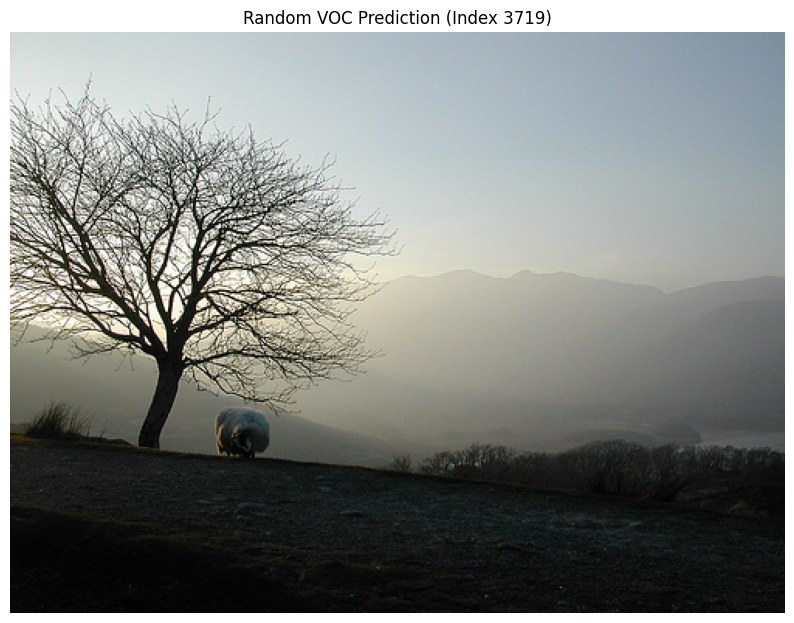

In [59]:
show_random_prediction(dataset, model, VOC_CLASSES, device)

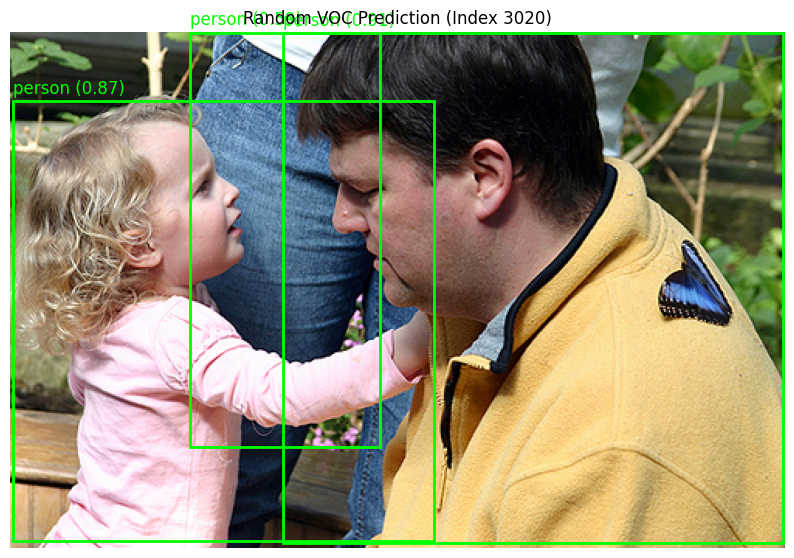

In [61]:
show_random_prediction(dataset, model, VOC_CLASSES, device)

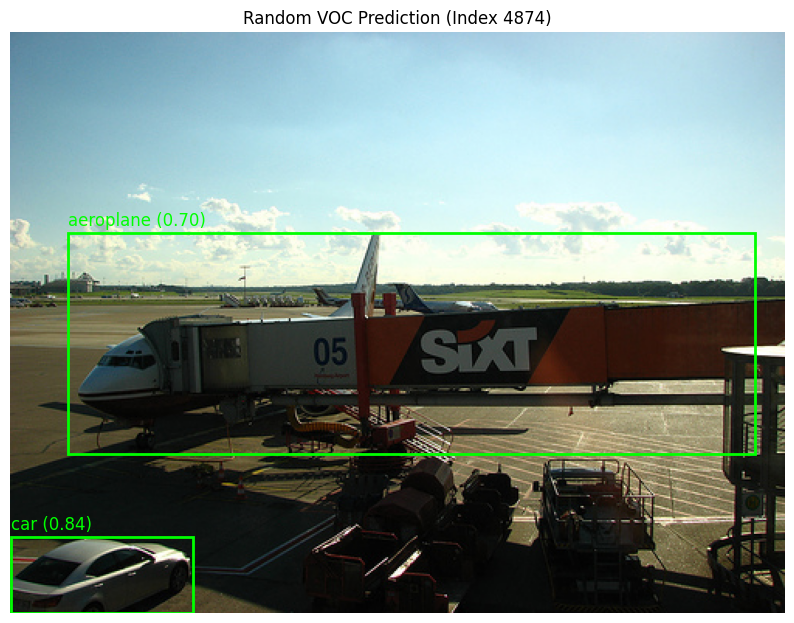

In [62]:
show_random_prediction(dataset, model, VOC_CLASSES, device)

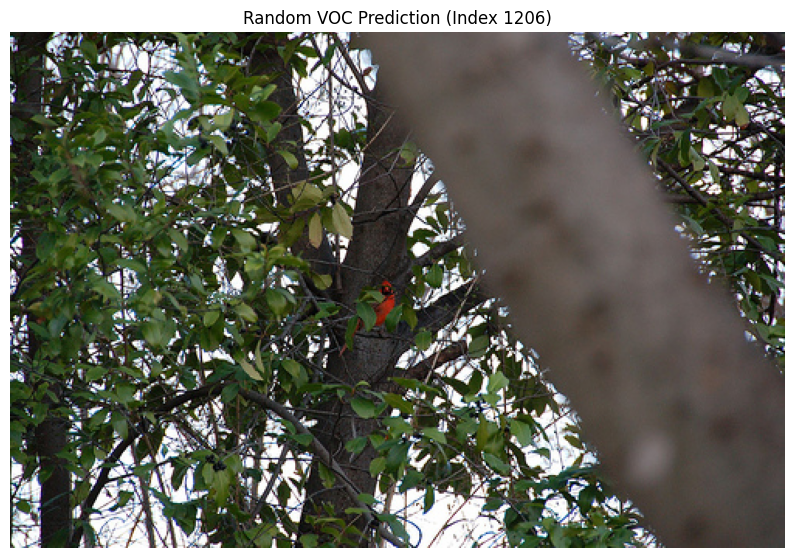

In [53]:
show_random_prediction(dataset, model, VOC_CLASSES, device,0.75)

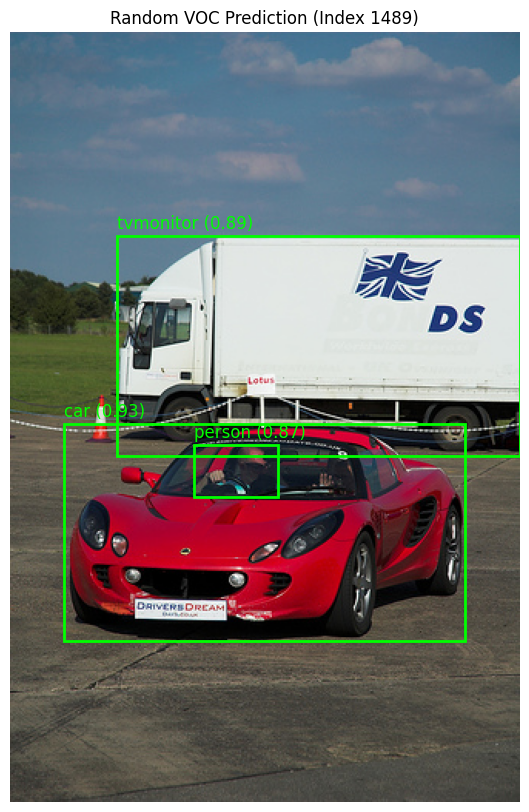

In [54]:
show_random_prediction(dataset, model, VOC_CLASSES, device)

In [17]:
results

{'map': tensor(0.5856),
 'map_50': tensor(0.5856),
 'map_75': tensor(-1.),
 'map_small': tensor(0.3708),
 'map_medium': tensor(0.5499),
 'map_large': tensor(0.6229),
 'mar_1': tensor(0.3943),
 'mar_10': tensor(0.6453),
 'mar_100': tensor(0.6789),
 'mar_small': tensor(0.6535),
 'mar_medium': tensor(0.6732),
 'mar_large': tensor(0.6854),
 'map_per_class': tensor([0.0000, 0.8533, 0.8499, 0.6627, 0.6783, 0.8879, 0.8211, 0.9224, 0.6526,
         0.8923, 0.0000, 0.9062, 0.9196, 0.0000, 0.8884, 0.0000, 0.8586, 0.0000,
         0.9181, 0.0000]),
 'mar_100_per_class': tensor([0.0000, 0.9711, 0.9507, 0.9450, 0.9139, 0.9625, 0.9795, 0.9871, 0.9703,
         0.9885, 0.0000, 0.9871, 0.9866, 0.0000, 0.9838, 0.0000, 0.9670, 0.0000,
         0.9848, 0.0000]),
 'classes': tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19, 20], dtype=torch.int32)}